 Iris Dataset Loaded for Clustering!
   sepal length (cm)  sepal width (cm)  petal length (cm)  petal width (cm)
0                5.1               3.5                1.4               0.2
1                4.9               3.0                1.4               0.2
2                4.7               3.2                1.3               0.2
3                4.6               3.1                1.5               0.2
4                5.0               3.6                1.4               0.2 



C:\ProgramData\anaconda3\Lib\site-packages\sklearn\cluster\_kmeans.py:1419: UserWarning: KMeans is known to have a memory leak on Windows with MKL, when there are less chunks than available threads. You can avoid it by setting the environment variable OMP_NUM_THREADS=1.
  warnings.warn(
C:\ProgramData\anaconda3\Lib\site-packages\sklearn\cluster\_kmeans.py:1419: UserWarning: KMeans is known to have a memory leak on Windows with MKL, when there are less chunks than available threads. You can avoid it by setting the environment variable OMP_NUM_THREADS=1.
  warnings.warn(
C:\ProgramData\anaconda3\Lib\site-packages\sklearn\cluster\_kmeans.py:1419: UserWarning: KMeans is known to have a memory leak on Windows with MKL, when there are less chunks than available threads. You can avoid it by setting the environment variable OMP_NUM_THREADS=1.
  warnings.warn(
C:\ProgramData\anaconda3\Lib\site-packages\sklearn\cluster\_kmeans.py:1419: UserWarning: KMeans is known to have a memory leak on Window

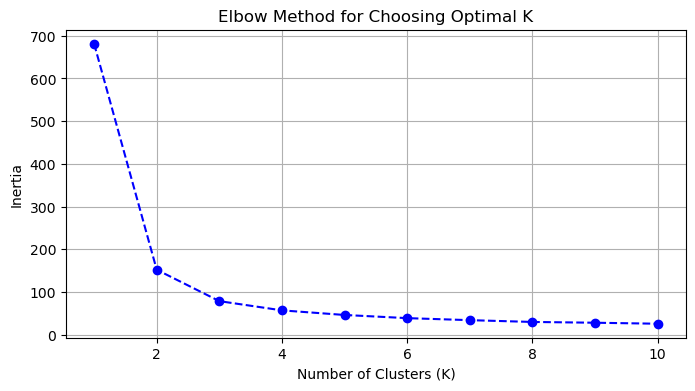

C:\ProgramData\anaconda3\Lib\site-packages\sklearn\cluster\_kmeans.py:1419: UserWarning: KMeans is known to have a memory leak on Windows with MKL, when there are less chunks than available threads. You can avoid it by setting the environment variable OMP_NUM_THREADS=1.
  warnings.warn(


--- K-MEANS CLUSTER CENTERS ---
[[5.9016129  2.7483871  4.39354839 1.43387097]
 [5.006      3.428      1.462      0.246     ]
 [6.85       3.07368421 5.74210526 2.07105263]] 



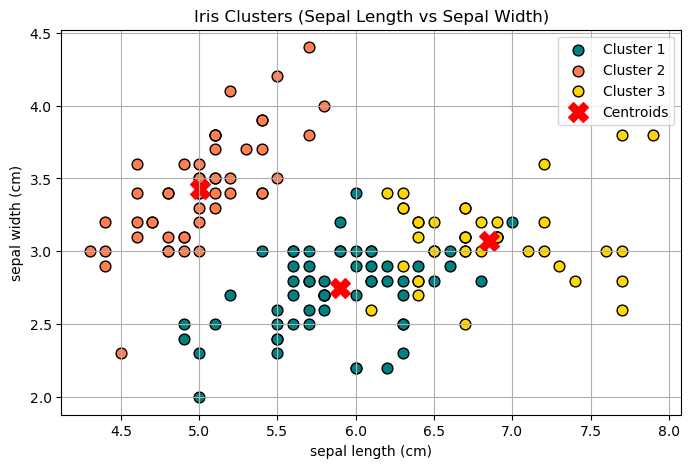

 Model saved as 'kmeans_iris_model.pkl'


In [1]:
# ========================================================
# TASK 1: IRIS FLOWER CLUSTERING USING K-MEANS
# ========================================================

import joblib
import matplotlib.pyplot as plt
import pandas as pd
from sklearn.cluster import KMeans
from sklearn.datasets import load_iris

# 1. Load Dataset
iris = load_iris()
X = iris.data
y = iris.target
feature_names = iris.feature_names

df = pd.DataFrame(X, columns=feature_names)
print(" Iris Dataset Loaded for Clustering!")
print(df.head(), "\n")

# 2. Elbow Method to choose K
inertia = []
K_range = range(1, 11)
for k in K_range:
    kmeans_temp = KMeans(n_clusters=k, random_state=42, n_init=10)
    kmeans_temp.fit(X)
    inertia.append(kmeans_temp.inertia_)

plt.figure(figsize=(8, 4))
plt.plot(K_range, inertia, marker="o", color="blue", linestyle="--")
plt.title("Elbow Method for Choosing Optimal K")
plt.xlabel("Number of Clusters (K)")
plt.ylabel("Inertia")
plt.grid(True)
plt.show()

# 3. Apply K-Means (K=3)
kmeans = KMeans(n_clusters=3, random_state=42, n_init=10)
predicted_labels = kmeans.fit_predict(X)

print("--- K-MEANS CLUSTER CENTERS ---")
print(kmeans.cluster_centers_, "\n")

# 4. Visualize Clusters (Using Sepal Length vs Sepal Width)
plt.figure(figsize=(8, 5))
colors = ["teal", "coral", "gold"]
for i in range(3):
    plt.scatter(
        X[predicted_labels == i, 0],
        X[predicted_labels == i, 1],
        label=f"Cluster {i+1}",
        c=colors[i],
        edgecolor="k",
        s=60,
    )

plt.scatter(
    kmeans.cluster_centers_[:, 0],
    kmeans.cluster_centers_[:, 1],
    c="red",
    marker="X",
    s=200,
    label="Centroids",
)
plt.title("Iris Clusters (Sepal Length vs Sepal Width)")
plt.xlabel(feature_names[0])
plt.ylabel(feature_names[1])
plt.legend()
plt.grid(True)
plt.show()

# 5. Save the Clustering Model
joblib.dump(kmeans, "kmeans_iris_model.pkl")
print(" Model saved as 'kmeans_iris_model.pkl'")

In [2]:
# ========================================================
# SCRIPT TO EXPORT IRIS DATASET TO A CSV FILE
# ========================================================

import pandas as pd
from sklearn.datasets import load_iris

# Load the built-in Iris dataset
iris = load_iris()

# Create a DataFrame with features
df_iris = pd.DataFrame(iris.data, columns=iris.feature_names)

# Add the target column (true species labels)
df_iris["species"] = iris.target

# Export the DataFrame to a CSV file without the row index
df_iris.to_csv("iris_dataset.csv", index=False)

print("✅ Success: 'iris_dataset.csv' has been generated on your Jupyter dashboard!")

✅ Success: 'iris_dataset.csv' has been generated on your Jupyter dashboard!
